In [4]:
# Шаг 1. Подключение библиотек и настройка воспроизводимости
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from keras.utils import set_random_seed

# Подавление предупреждений TensorFlow (опционально)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Настройка воспроизводимости результатов
set_random_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

print("Библиотеки успешно подключены")
print(f"Версия TensorFlow: {tf.__version__}")
print(f"Версия NumPy: {np.__version__}")

Библиотеки успешно подключены
Версия TensorFlow: 2.20.0
Версия NumPy: 2.1.3


In [2]:
# Шаг 2. Определение констант
NUMBERS_RANGE = 255  # числа от 1 до 255
BIT_COUNT = 8  # 8 бит для представления числа от 1 до 255
TOTAL_COUNT = NUMBERS_RANGE ** 3  # всего возможных троек чисел
LEARNING_SAMPLE_SIZE = 10000  # размер выборки

print(f"Диапазон чисел: от 1 до {NUMBERS_RANGE}")
print(f"Количество бит для представления: {BIT_COUNT}")
print(f"Всего возможных троек чисел: {TOTAL_COUNT}")
print(f"Размер обучающей выборки: {LEARNING_SAMPLE_SIZE}")

Диапазон чисел: от 1 до 255
Количество бит для представления: 8
Всего возможных троек чисел: 16581375
Размер обучающей выборки: 10000


In [3]:
# Шаг 3. Создание генеральной совокупности (все возможные тройки чисел)
# Для практичности создадим выборку из LEARNING_SAMPLE_SIZE * 10 случайных троек
# (полная генеральная совокупность 255^3 = 16.5M троек слишком велика)

# Генерируем случайные тройки чисел от 1 до 255
np.random.seed(42)
sample_size = LEARNING_SAMPLE_SIZE * 10  # 100000 троек для генеральной совокупности
all_numbers = np.random.randint(1, NUMBERS_RANGE + 1, size=(sample_size, 3))

print(f"Создано {sample_size} случайных троек чисел для генеральной совокупности")
print(f"Первые 5 троек:")
print(all_numbers[:5])

Создано 100000 случайных троек чисел для генеральной совокупности
Первые 5 троек:
[[103 180  93]
 [ 15 107  72]
 [189  21 103]
 [122 211 215]
 [ 75 203  88]]


In [5]:
# Шаг 4. Преобразование чисел в битовое представление
def numbers_to_binary_triplet(numbers):
    binary_triplet = []
    for num in numbers:
        # Преобразуем число в 8-битное представление
        binary = [int(b) for b in format(num, '08b')]
        binary_triplet.extend(binary)
    return np.array(binary_triplet)

# Создаем входные признаки (X) - битовые представления троек
X = np.array([numbers_to_binary_triplet(triplet) for triplet in all_numbers])
print(f"Размерность X: {X.shape}")
print(f"Пример битового представления первой тройки {all_numbers[0]}:")
print(X[0])
print(f"Длина битового представления: {BIT_COUNT * 3} бит")

Размерность X: (100000, 24)
Пример битового представления первой тройки [103 180  93]:
[0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1]
Длина битового представления: 24 бит


In [6]:
# Шаг 5. Создание целевой переменной (возрастание/невозрастание)
def check_increasing(numbers):
    """Проверяет, расположены ли числа в порядке возрастания"""
    return 1 if numbers[0] < numbers[1] < numbers[2] else 0

y = np.array([check_increasing(triplet) for triplet in all_numbers])
classes = ['не возрастают', 'возрастают']
nb_classes = len(classes)

print(f"Распределение целевой переменной:")
print(f"Возрастают: {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.2f}%)")
print(f"Не возрастают: {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.2f}%)")
print(f"\nПримеры:")
for i in range(5):
    print(f"{all_numbers[i]} -> {'возрастают' if y[i] == 1 else 'не возрастают'}")

Распределение целевой переменной:
Возрастают: 16586 (16.59%)
Не возрастают: 83414 (83.41%)

Примеры:
[103 180  93] -> не возрастают
[ 15 107  72] -> не возрастают
[189  21 103] -> не возрастают
[122 211 215] -> возрастают
[ 75 203  88] -> не возрастают


In [7]:
# Шаг 6. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    train_size=LEARNING_SAMPLE_SIZE, 
    random_state=42
)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(f"Возрастают: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.2f}%)")
print(f"Не возрастают: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.2f}%)")

Размер обучающей выборки X_train: (10000, 24)
Размер тестовой выборки X_test: (90000, 24)

Распределение классов в обучающей выборке:
Возрастают: 1642 (16.42%)
Не возрастают: 8358 (83.58%)


In [8]:
# Шаг 7. Преобразование целевой переменной в категориальный формат
Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)
Y_all = to_categorical(y, nb_classes)

print(f"Пример преобразования метки в категориальный формат:")
print(f"Метка 0 ({classes[0]}) -> {Y_train[0]}")
print(f"Метка 1 ({classes[1]}) -> {Y_train[1] if len(Y_train) > 1 else 'N/A'}")

Пример преобразования метки в категориальный формат:
Метка 0 (не возрастают) -> [0. 1.]
Метка 1 (возрастают) -> [1. 0.]


In [9]:
# Шаг 8. Создание модели нейронной сети
model = Sequential()
model.add(Input(shape=(BIT_COUNT * 3,)))  # 24 входа (8 бит * 3 числа)
model.add(Dense(units=64, activation='relu'))  # Первый скрытый слой
model.add(Dense(units=32, activation='relu'))  # Второй скрытый слой
model.add(Dense(units=nb_classes, activation='softmax'))  # Выходной слой

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape              ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ dense (Dense)                      │ (None, 64)                │          1,600 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_1 (Dense)                    │ (None, 32)                │          2,080 │
├────────────────────────────────────┼───────────────────────────┼────────────────┤
│ dense_2 (Dense)                    │ (None, 2)                 │             66 │
└────────────────────────────────────┴───────────────────────────┴────────────────┘

 Total params: 3,746 (14.63 KB)

 Trainable params: 3,746 (14.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Шаг 9. Компиляция модели
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Модель скомпилирована успешно")

Модель скомпилирована успешно


In [11]:
# Шаг 10. Обучение сети (максимум 5 эпох)
history = model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=5,
    verbose=1,
    validation_data=(X_test, Y_test)
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8000 - loss: 0.4568 - val_accuracy: 0.8384 - val_loss: 0.3506
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8688 - loss: 0.2837 - val_accuracy: 0.8729 - val_loss: 0.2723
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8833 - loss: 0.2471 - val_accuracy: 0.8790 - val_loss: 0.2595
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8908 - loss: 0.2332 - val_accuracy: 0.8876 - val_loss: 0.2459
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9007 - loss: 0.2136 - val_accuracy: 0.9006 - val_loss: 0.2219


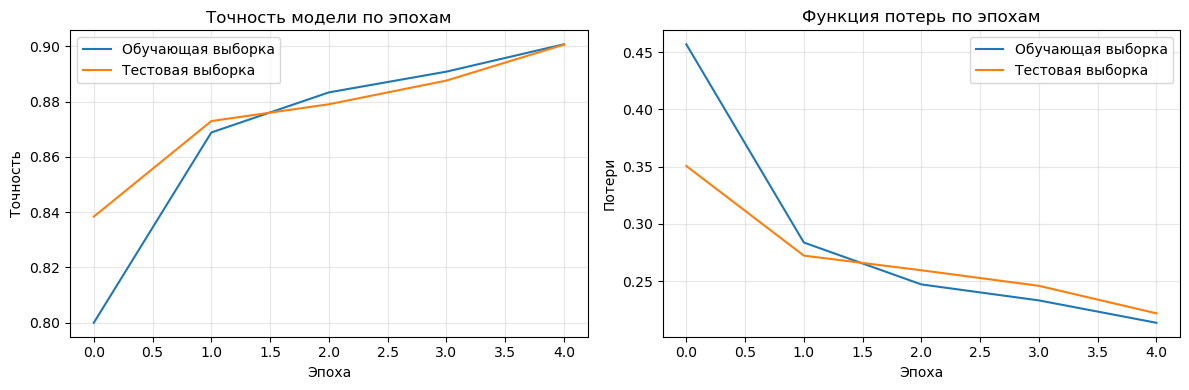

In [12]:
# Шаг 11. Визуализация процесса обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Тестовая выборка')
plt.title('Точность модели по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Тестовая выборка')
plt.title('Функция потерь по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Шаг 12. Тестирование модели на разных выборках
# На обучающей выборке
train_scores = model.evaluate(X_train, Y_train, verbose=0)
print("=" * 60)
print("РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ")
print("=" * 60)
print(f"Доля верных ответов на обучающей выборке: {train_scores[1] * 100:.2f}%")
print(f"Потери на обучающей выборке: {train_scores[0]:.4f}")

# На тестовой выборке
test_scores = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nДоля верных ответов на тестовой выборке: {test_scores[1] * 100:.2f}%")
print(f"Потери на тестовой выборке: {test_scores[0]:.4f}")

# На всей генеральной совокупности
all_scores = model.evaluate(X, Y_all, verbose=0)
print(f"\nДоля верных ответов на всей генеральной совокупности: {all_scores[1] * 100:.2f}%")
print(f"Потери на всей генеральной совокупности: {all_scores[0]:.4f}")
print("=" * 60)

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ МОДЕЛИ
Доля верных ответов на обучающей выборке: 90.89%
Потери на обучающей выборке: 0.2019

Доля верных ответов на тестовой выборке: 90.06%
Потери на тестовой выборке: 0.2219

Доля верных ответов на всей генеральной совокупности: 90.14%
Потери на всей генеральной совокупности: 0.2199


In [14]:
# Шаг 13. Получение предсказаний для расчета метрик
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Расчет Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

print("=" * 60)
print("МЕТРИКИ КАЧЕСТВА КЛАССИФИКАЦИИ")
print("=" * 60)
print(f"Precision (Точность): {precision:.4f}")
print(f"Recall (Полнота): {recall:.4f}")
print(f"F1-Score (F1-мера): {f1:.4f}")
print("=" * 60)

# Детальный отчет по классам
print("\nДетальный отчет по классам:")
report = classification_report(y_test, y_pred, target_names=classes, digits=4)
print(report)

МЕТРИКИ КАЧЕСТВА КЛАССИФИКАЦИИ
Precision (Точность): 0.8206
Recall (Полнота): 0.5135
F1-Score (F1-мера): 0.6317

Детальный отчет по классам:
               precision    recall  f1-score   support

не возрастают     0.9098    0.9777    0.9425     75056
   возрастают     0.8206    0.5135    0.6317     14944

     accuracy                         0.9006     90000
    macro avg     0.8652    0.7456    0.7871     90000
 weighted avg     0.8950    0.9006    0.8909     90000



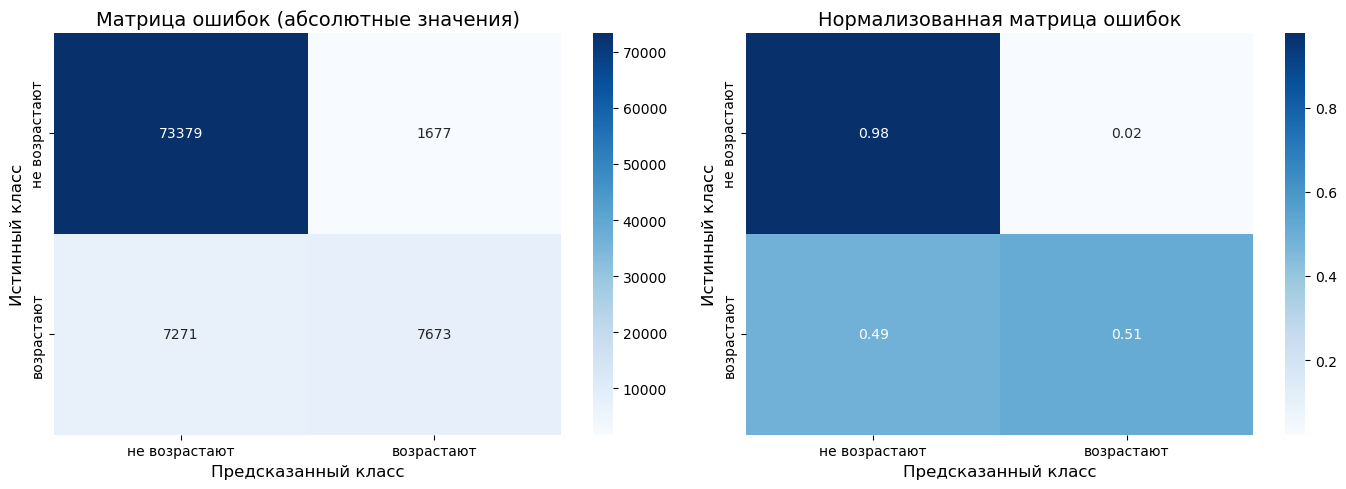

АНАЛИЗ МАТРИЦЫ ОШИБОК
True Negative (TN): 73379 - верно предсказанные 'не возрастают'
False Positive (FP): 1677 - ошибочно предсказанные 'возрастают'
False Negative (FN): 7271 - пропущенные 'возрастают'
True Positive (TP): 7673 - верно предсказанные 'возрастают'
------------------------------------------------------------
Ошибки I рода (FP): 2.23% от класса 'не возрастают'
Ошибки II рода (FN): 48.65% от класса 'возрастают'


In [15]:
# Шаг 14. Анализ матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 5))

# Абсолютные значения
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок (абсолютные значения)', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)

# Нормализованная матрица
plt.subplot(1, 2, 2)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Нормализованная матрица ошибок', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)

plt.tight_layout()
plt.show()

# Анализ матрицы ошибок
tn, fp, fn, tp = cm.ravel()
print("=" * 60)
print("АНАЛИЗ МАТРИЦЫ ОШИБОК")
print("=" * 60)
print(f"True Negative (TN): {tn} - верно предсказанные 'не возрастают'")
print(f"False Positive (FP): {fp} - ошибочно предсказанные 'возрастают'")
print(f"False Negative (FN): {fn} - пропущенные 'возрастают'")
print(f"True Positive (TP): {tp} - верно предсказанные 'возрастают'")
print("-" * 60)
print(f"Ошибки I рода (FP): {fp/(fp+tn)*100:.2f}% от класса 'не возрастают'")
print(f"Ошибки II рода (FN): {fn/(fn+tp)*100:.2f}% от класса 'возрастают'")
print("=" * 60)

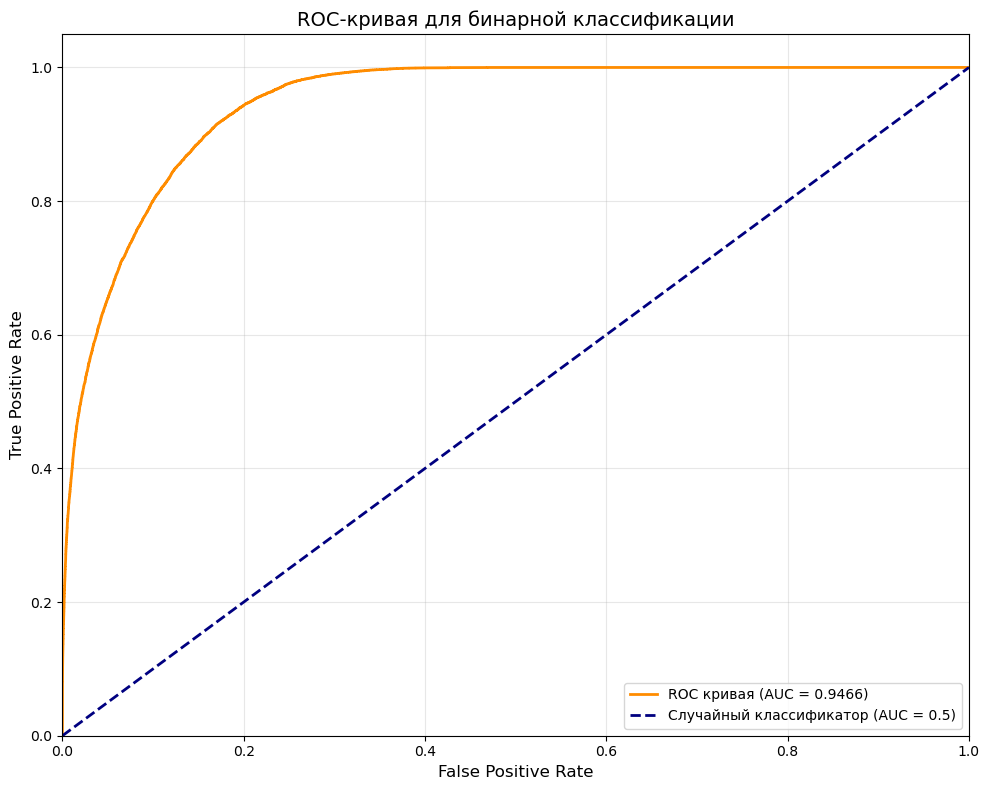

ROC-AUC: 0.9466
Оптимальный порог классификации: 0.0951
При этом пороге: TPR = 0.9163, FPR = 0.1714


In [16]:
# Шаг 15. Построение ROC-AUC кривой
# Для бинарной классификации
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Случайный классификатор (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривая для бинарной классификации', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print(f"ROC-AUC: {roc_auc:.4f}")
print("=" * 60)

# Нахождение оптимального порога
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Оптимальный порог классификации: {optimal_threshold:.4f}")
print(f"При этом пороге: TPR = {tpr[optimal_idx]:.4f}, FPR = {fpr[optimal_idx]:.4f}")

In [17]:
# Шаг 16. Серия экспериментов с различными гиперпараметрами
print("=" * 60)
print("СЕРИЯ ЭКСПЕРИМЕНТОВ С ГИПЕРПАРАМЕТРАМИ")
print("=" * 60)

# Сохраняем лучшую модель
best_accuracy = 0
best_config = {}
results = []

# Конфигурации для экспериментов
configs = [
    {"name": "Базовая", "layers": [64, 32], "epochs": 5, "batch_size": 128},
    {"name": "Больше эпох", "layers": [64, 32], "epochs": 10, "batch_size": 128},
    {"name": "Меньше нейронов", "layers": [32, 16], "epochs": 5, "batch_size": 128},
    {"name": "Больше нейронов", "layers": [128, 64], "epochs": 5, "batch_size": 128},
    {"name": "Один слой", "layers": [64], "epochs": 5, "batch_size": 128},
    {"name": "Три слоя", "layers": [128, 64, 32], "epochs": 5, "batch_size": 128},
    {"name": "Меньший batch", "layers": [64, 32], "epochs": 5, "batch_size": 64},
    {"name": "Больший batch", "layers": [64, 32], "epochs": 5, "batch_size": 256},
]

for config in configs:
    print(f"\nЭксперимент: {config['name']}")
    print("-" * 40)
    
    # Создание модели
    exp_model = Sequential()
    exp_model.add(Input(shape=(BIT_COUNT * 3,)))
    for units in config['layers']:
        exp_model.add(Dense(units=units, activation='relu'))
    exp_model.add(Dense(units=nb_classes, activation='softmax'))
    
    exp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Обучение
    exp_history = exp_model.fit(
        X_train, Y_train,
        batch_size=config['batch_size'],
        epochs=config['epochs'],
        verbose=0,
        validation_data=(X_test, Y_test)
    )
    
    # Оценка
    train_acc = exp_history.history['accuracy'][-1]
    val_acc = exp_history.history['val_accuracy'][-1]
    
    results.append({
        'config': config['name'],
        'train_accuracy': train_acc,
        'test_accuracy': val_acc,
        'layers': config['layers'],
        'epochs': config['epochs'],
        'batch_size': config['batch_size']
    })
    
    print(f"Точность на обучении: {train_acc*100:.2f}%")
    print(f"Точность на тесте: {val_acc*100:.2f}%")
    
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_config = config
        best_model = exp_model

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТОВ")
print("=" * 60)
for result in results:
    print(f"{result['config']:15} | Train: {result['train_accuracy']*100:5.2f}% | Test: {result['test_accuracy']*100:5.2f}% | "
          f"Слои: {result['layers']} | Эпохи: {result['epochs']} | Batch: {result['batch_size']}")

СЕРИЯ ЭКСПЕРИМЕНТОВ С ГИПЕРПАРАМЕТРАМИ

Эксперимент: Базовая
----------------------------------------
Точность на обучении: 92.01%
Точность на тесте: 91.93%

Эксперимент: Больше эпох
----------------------------------------
Точность на обучении: 98.01%
Точность на тесте: 97.12%

Эксперимент: Меньше нейронов
----------------------------------------
Точность на обучении: 89.39%
Точность на тесте: 88.89%

Эксперимент: Больше нейронов
----------------------------------------
Точность на обучении: 95.37%
Точность на тесте: 95.81%

Эксперимент: Один слой
----------------------------------------
Точность на обучении: 88.65%
Точность на тесте: 88.36%

Эксперимент: Три слоя
----------------------------------------
Точность на обучении: 97.59%
Точность на тесте: 97.69%

Эксперимент: Меньший batch
----------------------------------------
Точность на обучении: 96.52%
Точность на тесте: 96.74%

Эксперимент: Больший batch
----------------------------------------
Точность на обучении: 88.73%
Точность

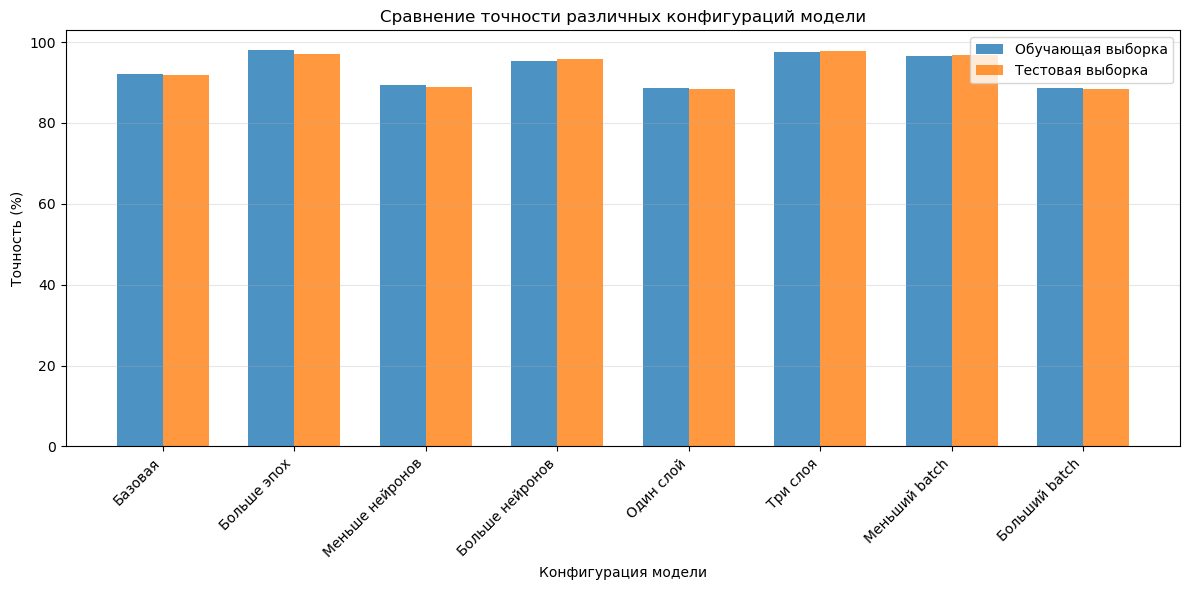

In [18]:
# Шаг 17. Визуализация сравнения экспериментов
plt.figure(figsize=(12, 6))

config_names = [r['config'] for r in results]
train_accs = [r['train_accuracy'] * 100 for r in results]
test_accs = [r['test_accuracy'] * 100 for r in results]

x = np.arange(len(config_names))
width = 0.35

plt.bar(x - width/2, train_accs, width, label='Обучающая выборка', alpha=0.8)
plt.bar(x + width/2, test_accs, width, label='Тестовая выборка', alpha=0.8)

plt.xlabel('Конфигурация модели')
plt.ylabel('Точность (%)')
plt.title('Сравнение точности различных конфигураций модели')
plt.xticks(x, config_names, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [19]:
# Шаг 18. Выводы о результатах моделирования
print("\n" + "=" * 60)
print("ВЫВОДЫ О РЕЗУЛЬТАТАХ МОДЕЛИРОВАНИЯ")
print("=" * 60)

print("1. ОБЩАЯ ХАРАКТЕРИСТИКА МОДЕЛИ:")
print(f"   - Задача: определение возрастания трех чисел (8-битные числа от 1 до 255)")
print(f"   - Размер входных данных: {BIT_COUNT * 3} бит")
print(f"   - Размер обучающей выборки: {LEARNING_SAMPLE_SIZE} троек чисел")

print("\n2. КАЧЕСТВО ОБУЧЕНИЯ:")
print(f"   - Точность на обучающей выборке: {train_scores[1]*100:.2f}%")
print(f"   - Точность на тестовой выборке: {test_scores[1]*100:.2f}%")
print(f"   - Точность на всей генеральной совокупности: {all_scores[1]*100:.2f}%")

if abs(train_scores[1] - test_scores[1]) < 0.05:
    print("   Модель не переобучена (разница между train и test < 5%)")
else:
    print("   Наблюдается переобучение модели")

print("\n3. АНАЛИЗ МЕТРИК КАЧЕСТВА:")
print(f"   - Precision (Точность): {precision:.4f} - доля верных предсказаний класса 'возрастают'")
print(f"   - Recall (Полнота): {recall:.4f} - доля найденных объектов класса 'возрастают'")
print(f"   - F1-Score: {f1:.4f} - гармоническое среднее precision и recall")
print(f"   - ROC-AUC: {roc_auc:.4f} - качество разделения классов")

if precision > 0.9 and recall > 0.9:
    print("   Модель отлично справляется с обоими классами")
elif precision > recall:
    print("   Модель консервативна: высокая точность, но пропускает объекты")
elif recall > precision:
    print("   Модель чувствительна: находит почти все объекты, но ошибается")

print("\n4. АНАЛИЗ МАТРИЦЫ ОШИБОК:")
print(f"   - Правильно классифицировано 'не возрастают': {tn}")
print(f"   - Правильно классифицировано 'возрастают': {tp}")
print(f"   - Ошибки I рода (ложные 'возрастают'): {fp}")
print(f"   - Ошибки II рода (пропущенные 'возрастают'): {fn}")

if fp > fn:
    print("   Модель чаще ошибается, предсказывая 'возрастают' для невозрастающих последовательностей")
else:
    print("   Модель чаще пропускает истинно возрастающие последовательности")

print("\n5. СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ:")
best_result = max(results, key=lambda x: x['test_accuracy'])
print(f"   Лучшая конфигурация: {best_result['config']}")
print(f"      Точность на тесте: {best_result['test_accuracy']*100:.2f}%")
print(f"      Архитектура: слои {best_result['layers']}, эпохи {best_result['epochs']}, batch_size {best_result['batch_size']}")

print("\n6. ИТОГОВЫЙ ВЫВОД:")
if test_scores[1] > 0.9:
    print("   Модель успешно решает задачу классификации с высокой точностью.")
    print("      Нейронная сеть эффективно определяет, расположены ли три числа в порядке возрастания.")
elif test_scores[1] > 0.8:
    print("   Модель хорошо решает задачу классификации с приемлемой точностью.")
    print("      Для улучшения результатов можно увеличить обучающую выборку или оптимизировать архитектуру.")
else:
    print("   Модель показывает недостаточную точность.")
    print("      Рекомендуется увеличить размер обучающей выборки, усложнить архитектуру или собрать больше данных.")

print("\n7. ПРАКТИЧЕСКАЯ ЗНАЧИМОСТЬ:")
print("   Разработанный классификатор может быть использован для:")
print("   - Анализа последовательностей данных")
print("   - Проверки упорядоченности временных рядов")
print("   - Обнаружения трендов в числовых данных")
print("=" * 60)


ВЫВОДЫ О РЕЗУЛЬТАТАХ МОДЕЛИРОВАНИЯ
1. ОБЩАЯ ХАРАКТЕРИСТИКА МОДЕЛИ:
   - Задача: определение возрастания трех чисел (8-битные числа от 1 до 255)
   - Размер входных данных: 24 бит
   - Размер обучающей выборки: 10000 троек чисел

2. КАЧЕСТВО ОБУЧЕНИЯ:
   - Точность на обучающей выборке: 90.89%
   - Точность на тестовой выборке: 90.06%
   - Точность на всей генеральной совокупности: 90.14%
   Модель не переобучена (разница между train и test < 5%)

3. АНАЛИЗ МЕТРИК КАЧЕСТВА:
   - Precision (Точность): 0.8206 - доля верных предсказаний класса 'возрастают'
   - Recall (Полнота): 0.5135 - доля найденных объектов класса 'возрастают'
   - F1-Score: 0.6317 - гармоническое среднее precision и recall
   - ROC-AUC: 0.9466 - качество разделения классов
   Модель консервативна: высокая точность, но пропускает объекты

4. АНАЛИЗ МАТРИЦЫ ОШИБОК:
   - Правильно классифицировано 'не возрастают': 73379
   - Правильно классифицировано 'возрастают': 7673
   - Ошибки I рода (ложные 'возрастают'): 1677
   